# 04 — AR Aging & Collections

Explores the output of `src/collections/` (AR aging, DSO, collections
analytics, payment behavior, collection priority). See
`docs/kpi_definitions.md` for every formula used here.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
COLOR_PRIMARY = "#2A5CA6"
COLOR_RISK = "#C0392B"
COLOR_WARN = "#D68910"
COLOR_OK = "#2E8B57"
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


In [2]:
import json
ar = pd.read_csv(PROCESSED / "ar_aging.csv")
ar_summary = pd.read_csv(PROCESSED / "ar_aging_summary.csv")
dso_month = pd.read_csv(PROCESSED / "dso_by_month.csv")
behavior = pd.read_csv(PROCESSED / "payment_behavior.csv")
channel = pd.read_csv(PROCESSED / "collection_channel_effectiveness.csv")
queue = pd.read_csv(PROCESSED / "collection_priority_queue.csv")
with open(PROCESSED / "collections_summary.json") as f:
    summary = json.load(f)

print(f"Total open AR: {ar['outstanding_amount'].sum():,.2f} across {len(ar):,} invoices")
print(f"Overall DSO (trailing 90d): {summary['dso_overall']['dso_days']} days")
print(f"Collection rate (trailing 90d): {summary['collection_rate']['collection_rate_percent']}%")
print(f"Recovery rate: {summary['recovery_rate']['recovery_rate_percent']}%")

Total open AR: 2,892,376.38 across 3,844 invoices
Overall DSO (trailing 90d): 106.6 days
Collection rate (trailing 90d): 92.11%
Recovery rate: 16.34%


## AR aging composition

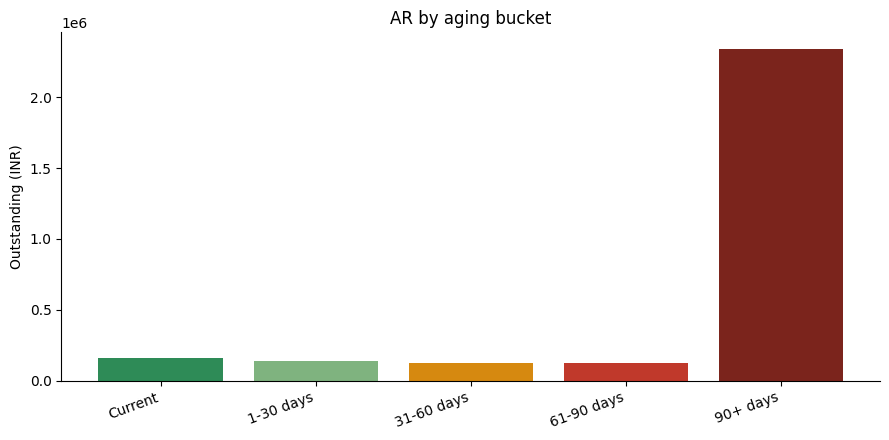

,invoice_count,total_outstanding,percent_of_total_ar
aging_bucket,,,
Current,169,"161,722.15",5.59
1-30 days,179,"138,615.08",4.79
31-60 days,155,"124,452.12",4.30
61-90 days,150,"127,197.90",4.40
90+ days,3191,"2,340,389.13",80.92


In [3]:
order = ["Current", "1-30 days", "31-60 days", "61-90 days", "90+ days"]
ar_summary = ar_summary.set_index("aging_bucket").reindex(order)
fig, ax = plt.subplots()
bucket_colors = ["#2E8B57", "#7FB37F", "#D68910", "#C0392B", "#7B241C"]
ax.bar(ar_summary.index, ar_summary["total_outstanding"], color=bucket_colors)
ax.set_ylabel("Outstanding (INR)")
ax.set_title("AR by aging bucket")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()
ar_summary

## DSO trend (monthly, current-period view)

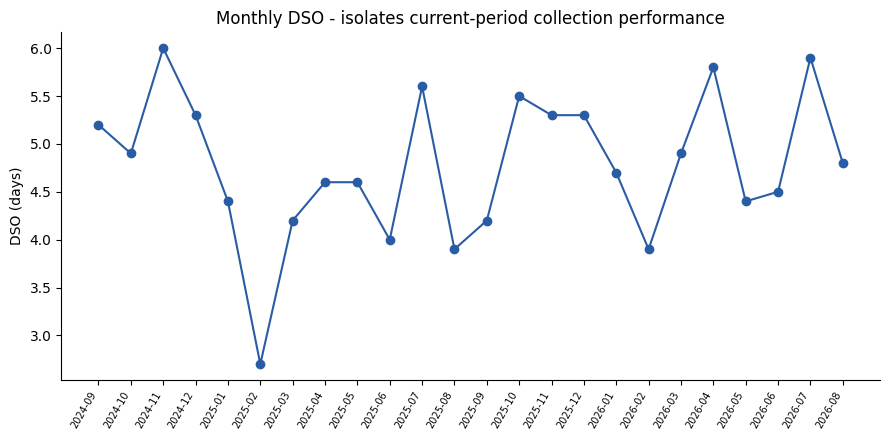

In [4]:
fig, ax = plt.subplots()
ax.plot(dso_month["month"], dso_month["dso_days"], marker="o", color=COLOR_PRIMARY)
ax.set_ylabel("DSO (days)")
ax.set_title("Monthly DSO - isolates current-period collection performance")
plt.xticks(rotation=60, ha="right", fontsize=7)
plt.tight_layout()
plt.show()

## Payer segment distribution

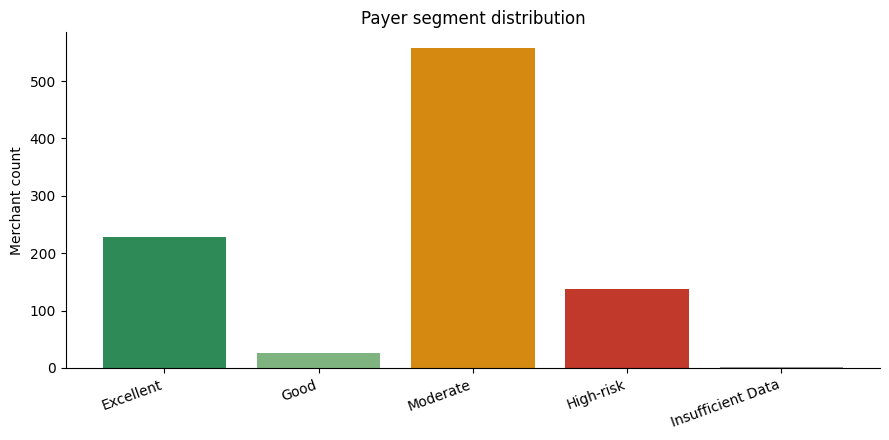

In [5]:
seg_counts = behavior["payer_segment"].value_counts().reindex(["Excellent", "Good", "Moderate", "High-risk", "Insufficient Data"]).dropna()
fig, ax = plt.subplots()
seg_colors = {"Excellent": COLOR_OK, "Good": "#7FB37F", "Moderate": COLOR_WARN, "High-risk": COLOR_RISK, "Insufficient Data": "#999999"}
ax.bar(seg_counts.index, seg_counts.values, color=[seg_colors[s] for s in seg_counts.index])
ax.set_ylabel("Merchant count")
ax.set_title("Payer segment distribution")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## Collection channel effectiveness

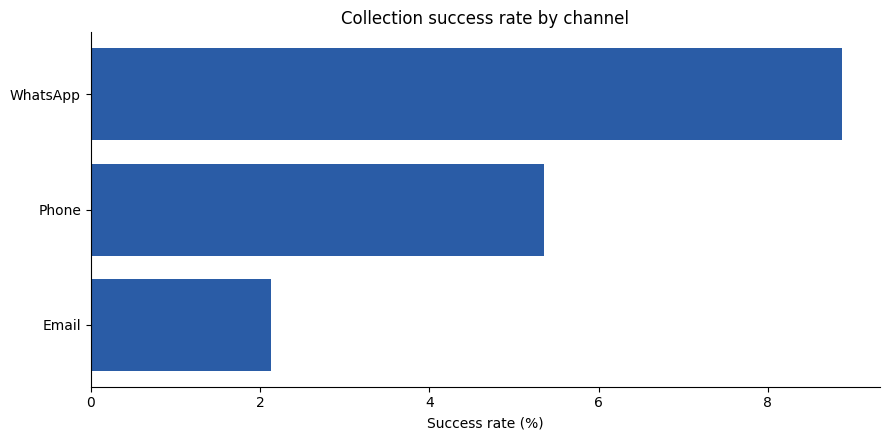

,contact_channel,total_activities,payments_received,success_rate_percent
0,WhatsApp,822,73,8.88
1,Phone,4352,233,5.35
2,Email,7126,152,2.13


In [6]:
fig, ax = plt.subplots()
channel_sorted = channel.sort_values("success_rate_percent", ascending=True)
ax.barh(channel_sorted["contact_channel"], channel_sorted["success_rate_percent"], color=COLOR_PRIMARY)
ax.set_xlabel("Success rate (%)")
ax.set_title("Collection success rate by channel")
plt.tight_layout()
plt.show()
channel

## Top 10 collection priority accounts

In [7]:
queue.head(10)[["priority_rank", "merchant_name", "merchant_segment", "outstanding_amount",
                 "days_overdue", "priority_tier", "recommended_action"]]

,priority_rank,merchant_name,merchant_segment,outstanding_amount,days_overdue,priority_tier,recommended_action
0,1,Mckinney-Wallace,Enterprise,"14,876.60",194,Critical,Immediate escalation - account manager + finan...
1,2,Buchanan LLC,Enterprise,"13,536.72",559,Critical,Immediate escalation - account manager + finan...
2,3,"Harvey, Randall and Hernandez",Mid-Market,"3,980.31",147,High,Phone + email follow-up within 48 hours
3,4,Galloway-Wyatt,Enterprise,"17,231.19",58,High,Phone + email follow-up within 48 hours
4,5,"Harvey, Randall and Hernandez",Mid-Market,"3,449.60",512,High,Phone + email follow-up within 48 hours
5,6,"Harvey, Randall and Hernandez",Mid-Market,"2,837.28",604,High,Phone + email follow-up within 48 hours
6,7,Good-Hodges,Mid-Market,"2,617.61",589,High,Phone + email follow-up within 48 hours
7,8,Vargas Ltd,Mid-Market,"5,824.61",239,High,Phone + email follow-up within 48 hours
8,9,"Harvey, Randall and Hernandez",Mid-Market,"2,227.21",209,High,Phone + email follow-up within 48 hours
9,10,Garcia-Jennings,Mid-Market,"2,226.22",362,High,Phone + email follow-up within 48 hours


## Takeaways

- 80.9% of open AR sits in the 90+ day bucket — see
  `docs/business_insights.md` insight #1.
- Headline DSO (~107 days) is inflated by the aged back-book; monthly DSO
  tells the more accurate current-performance story (insight #4).
- WhatsApp/Phone convert far better than Email despite getting the least
  volume — a channel-mix reallocation opportunity (insight #5).